In [1]:
"""The preprocessing pipeline prepared the dataset for machine learning.
Instead of repeating preprocessing, we load the processed training and testing datasets created in Notebook 03.
This keeps the workflow modular, reproducible, and efficient."""

' The preprocessing pipeline prepared the dataset for machine learning.\nInstead of repeating preprocessing, we load the processed training and testing datasets created in Notebook 03.\nThis keeps the workflow modular, reproducible, and efficient.'

In [4]:
import numpy as np
import joblib

import warnings
warnings.filterwarnings("ignore")
# NumPy is used to load the processed datasets,
# while Joblib helps us load and save trained models.

In [ ]:
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path("..")

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "models"
OUTPUT_PATH = PROJECT_ROOT / "outputs"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
(OUTPUT_PATH / "charts").mkdir(parents=True, exist_ok=True)

X_train = np.load(PROCESSED_PATH / "X_train.npy")
X_test = np.load(PROCESSED_PATH / "X_test.npy")
y_train = np.load(PROCESSED_PATH / "y_train.npy")
y_test = np.load(PROCESSED_PATH / "y_test.npy")

Mounted at /content/drive


In [7]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (5634, 46)
Testing Features : (1409, 46)

Training Labels : (5634,)
Testing Labels : (1409,)


In [9]:
print("Training Dataset")

print(np.unique(y_train, return_counts=True))

print()

print("Testing Dataset")

print(np.unique(y_test, return_counts=True))

Training Dataset
(array([0, 1]), array([4139, 1495]))

Testing Dataset
(array([0, 1]), array([1035,  374]))


In [10]:
# Linear Model
from sklearn.linear_model import LogisticRegression

# Tree-based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import time

print("All machine learning libraries imported successfully!")

All machine learning libraries imported successfully!


In [11]:
#Our first benchmark model. Future models will be compared against it.

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [12]:
# Let's measure how long training takes.

start_time = time.time()

logistic_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.4f} seconds")

Training completed in 0.0543 seconds


In [13]:
# Predict customer churn on unseen customers.

start_time = time.time()

y_pred = logistic_model.predict(X_test)

prediction_time = time.time() - start_time

print(f"Prediction completed in {prediction_time:.4f} seconds")

Prediction completed in 0.0034 seconds


In [14]:
#Instead of only Yes/No predictions, let's also get the probability of churn.

y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Probability predictions generated successfully!")

Probability predictions generated successfully!


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("Logistic Regression Performance")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print()

print(f"Training Time  : {training_time:.4f} sec")
print(f"Prediction Time: {prediction_time:.4f} sec")

Logistic Regression Performance
Accuracy : 0.8020
Precision: 0.6435
Recall   : 0.5695
F1 Score : 0.6043
ROC-AUC  : 0.8487

Training Time  : 0.0543 sec
Prediction Time: 0.0034 sec


In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[917 118]
 [161 213]]


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [18]:
# Our first non-linear machine learning model.

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [19]:
start_time = time.time()

decision_tree.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.4f} seconds")

Training completed in 0.0644 seconds


In [20]:
start_time = time.time()

y_pred = decision_tree.predict(X_test)

prediction_time = time.time() - start_time

print(f"Prediction completed in {prediction_time:.4f} seconds")

Prediction completed in 0.0041 seconds


In [21]:
# Probability of customer churn

y_prob = decision_tree.predict_proba(X_test)[:,1]

In [22]:
# Calculate performance metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("Decision Tree Performance")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print()
print(f"Training Time : {training_time:.4f} sec")
print(f"Prediction Time : {prediction_time:.4f} sec")

Decision Tree Performance
Accuracy : 0.7842
Precision: 0.5967
Recall   : 0.5775
F1 Score : 0.5870
ROC-AUC  : 0.8354

Training Time : 0.0644 sec
Prediction Time : 0.0041 sec


In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[889 146]
 [158 216]]


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1035
           1       0.60      0.58      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [25]:
# Random Forest Classifier

random_forest = RandomForestClassifier(

    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1

)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [26]:
start_time = time.time()

random_forest.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.4f} seconds")

Training completed in 2.8051 seconds


In [27]:
start_time = time.time()

y_pred = random_forest.predict(X_test)

prediction_time = time.time() - start_time

print(f"Prediction completed in {prediction_time:.4f} seconds")

Prediction completed in 0.1128 seconds


In [28]:
y_prob = random_forest.predict_proba(X_test)[:,1]

In [29]:
# Evaluate the Random Forest model.

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("Random Forest Performance")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print()

print(f"Training Time : {training_time:.4f} sec")
print(f"Prediction Time : {prediction_time:.4f} sec")

Random Forest Performance
Accuracy : 0.8034
Precision: 0.6559
Recall   : 0.5455
F1 Score : 0.5956
ROC-AUC  : 0.8510

Training Time : 2.8051 sec
Prediction Time : 0.1128 sec


In [30]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[928 107]
 [170 204]]


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [ ]:
import joblib

preprocessor = joblib.load(
    MODEL_PATH / "preprocessor.pkl"
)

In [34]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))

46


In [35]:
feature_importance = pd.DataFrame({

    "Feature": feature_names,
    "Importance": random_forest.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,numerical__Tenure Months,0.130758
2,numerical__Total Charges,0.116285
37,categorical__Contract_Month-to-month,0.086633
1,numerical__Monthly Charges,0.082170
19,categorical__Online Security_No,0.048869
17,categorical__Internet Service_Fiber optic,0.041499
28,categorical__Tech Support_No,0.040292
44,categorical__Payment Method_Electronic check,0.037856
10,categorical__Dependents_Yes,0.037663
39,categorical__Contract_Two year,0.034386


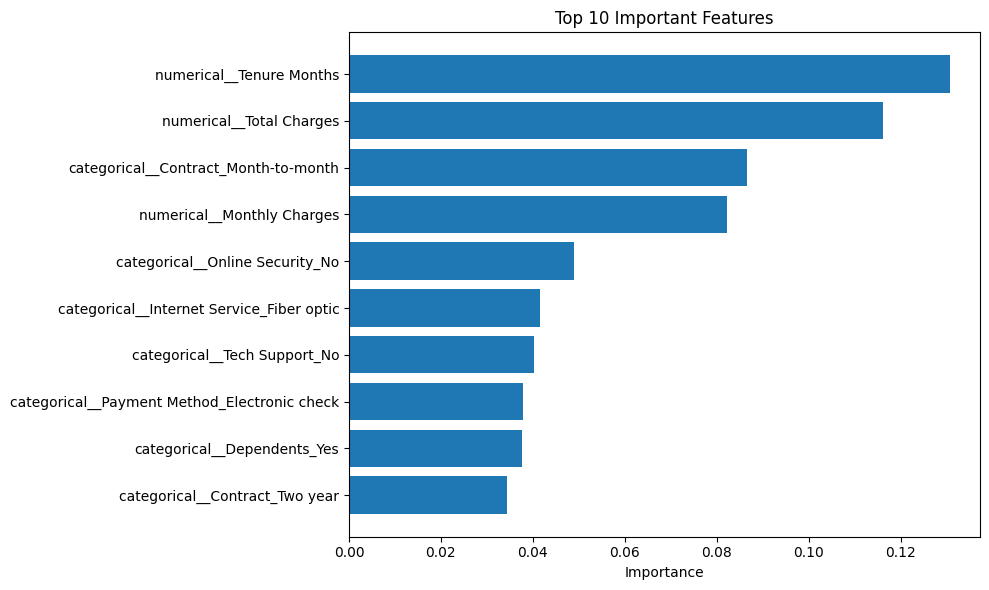

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.tight_layout()



plt.show()

In [42]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Remove unnecessary prefixes to make names easier to read
feature_names = [
    name.replace("categorical__", "")
        .replace("numerical__", "")
    for name in feature_names
]

# Display first few feature names
print(feature_names[:10])

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Gender_Female', 'Gender_Male', 'Senior Citizen_No', 'Senior Citizen_Yes', 'Partner_No', 'Partner_Yes', 'Dependents_No']


In [43]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Tenure Months,0.130758
2,Total Charges,0.116285
37,Contract_Month-to-month,0.086633
1,Monthly Charges,0.082170
19,Online Security_No,0.048869
17,Internet Service_Fiber optic,0.041499
28,Tech Support_No,0.040292
44,Payment Method_Electronic check,0.037856
10,Dependents_Yes,0.037663
39,Contract_Two year,0.034386


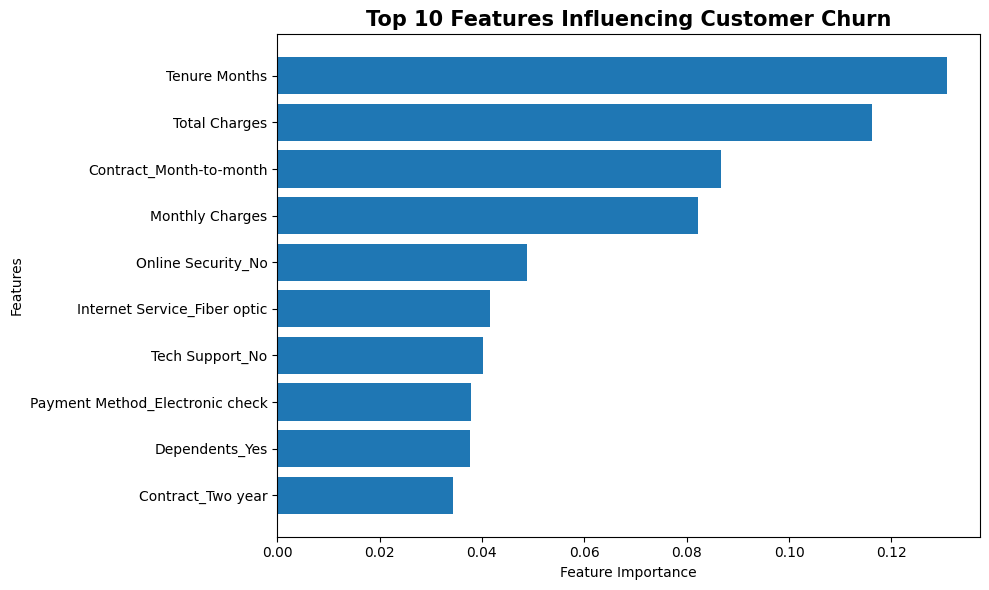

In [ ]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

plt.barh(
    top10["Feature"][::-1],
    top10["Importance"][::-1]
)

plt.title("Top 10 Features Influencing Customer Churn",
          fontsize=15,
          weight="bold")

plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.tight_layout()


plt.show()

In [46]:
# XGBoost is one of the most powerful ML algorithms for structured business data.

xgboost_model = XGBClassifier(

    random_state=42,

    n_estimators=200,

    max_depth=5,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="logloss"

)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [47]:
start_time = time.time()

xgboost_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.4f} seconds")

Training completed in 0.6767 seconds


In [48]:
start_time = time.time()

y_pred = xgboost_model.predict(X_test)

prediction_time = time.time() - start_time

print(f"Prediction completed in {prediction_time:.4f} seconds")

Prediction completed in 0.0332 seconds


In [49]:
y_prob = xgboost_model.predict_proba(X_test)[:,1]

In [50]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("="*50)
print("XGBoost Performance")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print()

print(f"Training Time : {training_time:.4f} sec")
print(f"Prediction Time : {prediction_time:.4f} sec")

XGBoost Performance
Accuracy : 0.8091
Precision: 0.6646
Recall   : 0.5668
F1 Score : 0.6118
ROC-AUC  : 0.8558

Training Time : 0.6767 sec
Prediction Time : 0.0332 sec


In [51]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[928 107]
 [162 212]]


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [53]:
feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": xgboost_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(10)

,Feature,Importance
37,Contract_Month-to-month,0.277697
17,Internet Service_Fiber optic,0.106422
19,Online Security_No,0.075816
10,Dependents_Yes,0.053079
39,Contract_Two year,0.039121
9,Dependents_No,0.037342
28,Tech Support_No,0.031721
20,Online Security_No internet service,0.021905
44,Payment Method_Electronic check,0.019579
38,Contract_One year,0.019288


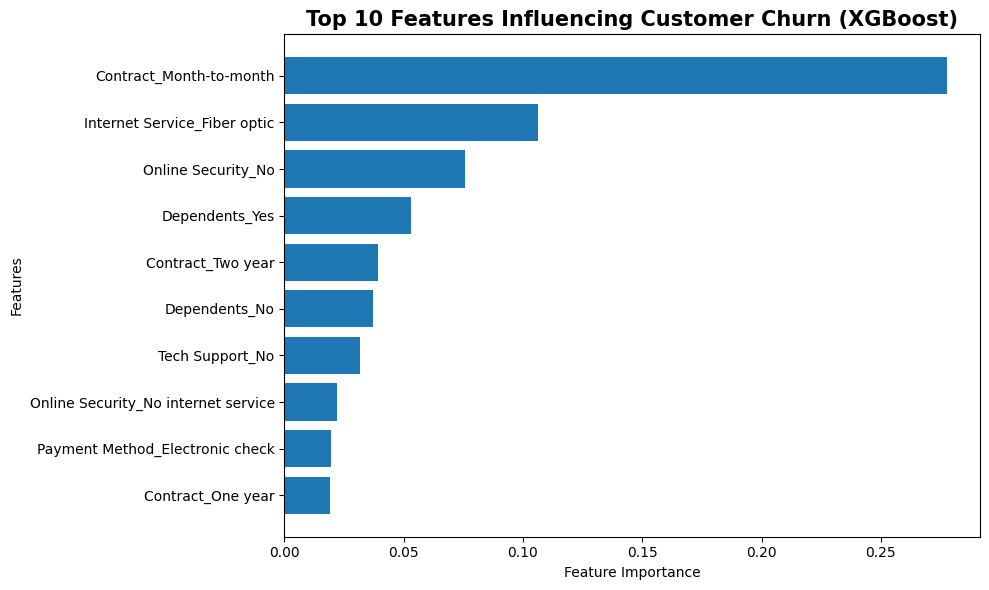

In [ ]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

plt.barh(

    top10["Feature"][::-1],

    top10["Importance"][::-1]

)

plt.title(

    "Top 10 Features Influencing Customer Churn (XGBoost)",

    fontsize=15,

    weight="bold"

)

plt.xlabel("Feature Importance")

plt.ylabel("Features")

plt.tight_layout()



plt.show()

In [56]:
# Microsoft's high-performance Gradient Boosting algorithm.

lightgbm_model = LGBMClassifier(

    random_state=42,

    n_estimators=200,

    learning_rate=0.05,

    max_depth=5,

    subsample=0.8,

    colsample_bytree=0.8

)

print("LightGBM model created successfully!")

LightGBM model created successfully!


In [57]:
# Measure how long the model takes to train.

start_time = time.time()

lightgbm_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.4f} seconds")

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [58]:
# Predict customer churn.

start_time = time.time()

y_pred = lightgbm_model.predict(X_test)

prediction_time = time.time() - start_time

print(f"Prediction completed in {prediction_time:.4f} seconds")

Prediction completed in 0.0324 seconds


In [59]:
y_prob = lightgbm_model.predict_proba(X_test)[:,1]

In [60]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("="*50)
print("LightGBM Performance")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print()

print(f"Training Time : {training_time:.4f} sec")
print(f"Prediction Time : {prediction_time:.4f} sec")

LightGBM Performance
Accuracy : 0.8048
Precision: 0.6571
Recall   : 0.5535
F1 Score : 0.6009
ROC-AUC  : 0.8525

Training Time : 0.4609 sec
Prediction Time : 0.0324 sec


In [61]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[927 108]
 [167 207]]


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [63]:
feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": lightgbm_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(10)

,Feature,Importance
1,Monthly Charges,1073
2,Total Charges,927
0,Tenure Months,632
44,Payment Method_Electronic check,172
9,Dependents_No,158
19,Online Security_No,139
28,Tech Support_No,97
37,Contract_Month-to-month,96
7,Partner_No,93
38,Contract_One year,89


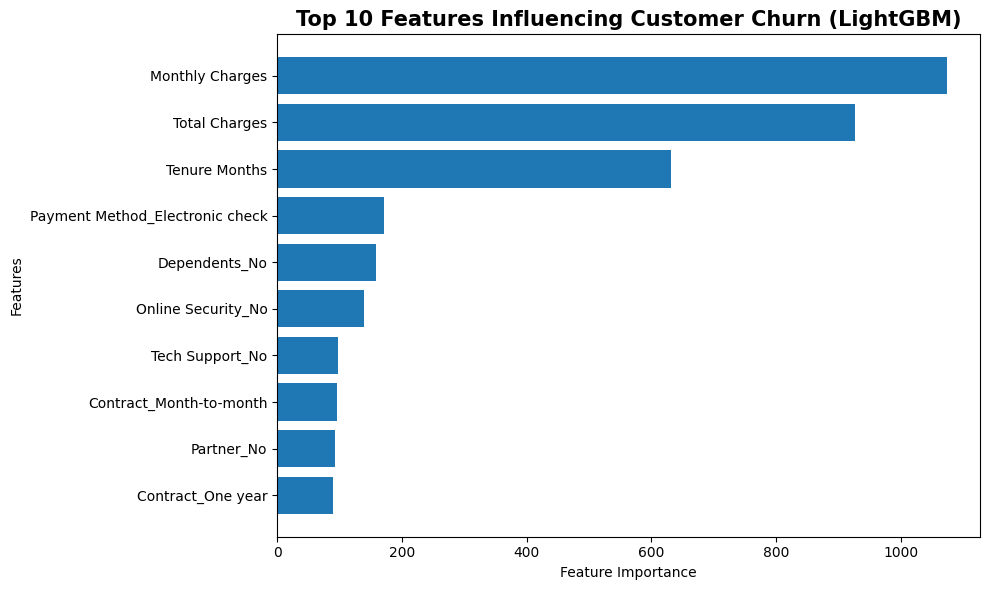

In [ ]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

plt.barh(

    top10["Feature"][::-1],

    top10["Importance"][::-1]

)

plt.title(

    "Top 10 Features Influencing Customer Churn (LightGBM)",

    fontsize=15,

    weight="bold"

)

plt.xlabel("Feature Importance")

plt.ylabel("Features")

plt.tight_layout()




plt.show()

Folders are ready!


In [67]:
# Compare all machine learning models

comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost",

        "LightGBM"

    ],

    "Accuracy":[

        0.8020,

        0.7842,

        0.8034,

        0.8091,

        0.8048

    ],

    "Precision":[

        0.6435,

        0.5967,

        0.6559,

        0.6646,

        0.6571

    ],

    "Recall":[

        0.5695,

        0.5775,

        0.5455,

        0.5668,

        0.5535

    ],

    "F1 Score":[

        0.6043,

        0.5870,

        0.5956,

        0.6118,

        0.6009

    ],

    "ROC-AUC":[

        0.8487,

        0.8354,

        0.8510,

        0.8558,

        0.8525

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8020,0.6435,0.5695,0.6043,0.8487
1,Decision Tree,0.7842,0.5967,0.5775,0.5870,0.8354
2,Random Forest,0.8034,0.6559,0.5455,0.5956,0.8510
3,XGBoost,0.8091,0.6646,0.5668,0.6118,0.8558
4,LightGBM,0.8048,0.6571,0.5535,0.6009,0.8525


In [68]:
# Sort by ROC-AUC (highest first)

comparison = comparison.sort_values(

    by="ROC-AUC",

    ascending=False

)

comparison.reset_index(

    drop=True,

    inplace=True

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.8091,0.6646,0.5668,0.6118,0.8558
1,LightGBM,0.8048,0.6571,0.5535,0.6009,0.8525
2,Random Forest,0.8034,0.6559,0.5455,0.5956,0.8510
3,Logistic Regression,0.8020,0.6435,0.5695,0.6043,0.8487
4,Decision Tree,0.7842,0.5967,0.5775,0.5870,0.8354


In [ ]:
comparison.to_csv(
    OUTPUT_PATH / "model_comparison.csv",
    index=False
)

print("Model comparison saved!")

Model comparison saved!


In [ ]:
import joblib

# Save the best-performing model

joblib.dump(
    xgboost_model,
    MODEL_PATH / "xgboost_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
joblib.dump(
    preprocessor,
    MODEL_PATH / "preprocessor.pkl"
)

print("Preprocessing pipeline saved!")

Preprocessing pipeline saved!


In [ ]:
feature_importance.to_csv(
    OUTPUT_PATH / "xgboost_feature_importance.csv",
    index=False
)

print("✅ Feature importance saved!")

Feature importance saved!


In [75]:
print("Models Trained")

print("- Logistic Regression")

print("- Decision Tree")

print("- Random Forest")

print("- XGBoost")

print("- LightGBM")

print()

print("Best Model Selected : XGBoost")

print()

print("Files Saved")

print("- xgboost_model.pkl")

print("- preprocessor.pkl")

print("- model_comparison.csv")

print("- xgboost_feature_importance.csv")

Models Trained
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM

Best Model Selected : XGBoost

Files Saved
- xgboost_model.pkl
- preprocessor.pkl
- model_comparison.csv
- xgboost_feature_importance.csv
